# Rashomon Multiplicity Analysis Demo

This notebook demonstrates the full pipeline for analyzing predictive multiplicity in Rashomon sets.

**Three core methods:**
1. **Observation-wise Variance** - Per-sample prediction instability
2. **PDP Variance (RPDP-II)** - Global feature effect instability  
3. **FME Variance** - Local feature effect instability


In [ ]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from src.data import prepare_data
from src.rashomon import build_rashomon_set, load_rashomon_result

import importlib
import src.metrics as _metrics
importlib.reload(_metrics)

compute_pdp_variance = _metrics.compute_pdp_variance
pdp_ranking = _metrics.pdp_ranking
fme_ranking = _metrics.fme_ranking
full_multiplicity_analysis = _metrics.full_multiplicity_analysis

from src.plots import (
    plot_rashomon_composition,
    plot_score_distribution,
    plot_variance_distribution,
    plot_variance_vs_prediction,
    plot_variance_metrics,
    plot_controversial_cases,
    plot_pdp_overlay,
    plot_pdp_top_features,
    plot_pdp_ranking,
    plot_fme_ranking,
    plot_fme_distribution,
    plot_variance_by_feature,
    plot_heatmap_variance_features
)

print("✅ All modules loaded successfully!")


✅ All modules loaded successfully!


## 1. Load Dataset

We'll use the COMPAS recidivism dataset - a high-stakes decision-making context where multiplicity matters.


In [25]:
# Load and prepare COMPAS dataset
data = prepare_data('compas', test_size=0.3, data_dir='../data')

# Extract components
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"\nFeatures: {feature_names}")


✅ Loaded compas: 7214 samples
   Features after preprocessing: 12
   Train: 5049, Test: 2165

Features: ['age', 'priors_count', 'sex_Female', 'sex_Male', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_F', 'c_charge_degree_M']


## 2. Build Rashomon Set

Train multiple model types (LogReg, Random Forest, GBM, MLP) with various hyperparameters and seeds.
Models within ε of the best AUC are included in the Rashomon set.


In [26]:
save_file = "../artifacts/rashomon_compas.joblib"

rashomon = build_rashomon_set(
    X_train, X_test, y_train, y_test,
    epsilon=0.01,
    metric='auc',
    seeds=[0, 1, 2],
    save_path=save_file
)
print(f"Saved Rashomon set to: {save_file}")



📦 Building Rashomon set (ε = 0.01)...
   Training LogReg...
   Training RF...
   Training GBM...
   Training MLP...
   ✅ Trained 261 models
   ✅ Rashomon set: 115/261 models
      Best auc: 0.7256
      Threshold: 0.7156
      Composition: {'LogReg': 24, 'RF': 3, 'GBM': 36, 'MLP': 52}
   💾 Saved Rashomon set to: ..\artifacts\rashomon_compas.joblib
Saved Rashomon set to: ../artifacts/rashomon_compas.joblib


In [27]:
def build_categorical_groups(preprocessor, feature_names):
    cat_entries = [t for t in preprocessor.transformers_ if t[0] == "cat"]
    if not cat_entries:
        return {}
    _, _, cat_cols = cat_entries[0]
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    name_to_idx = {n: i for i, n in enumerate(feature_names)}
    groups = {}
    for col, cats in zip(cat_cols, ohe.categories_):
        groups[col] = {cat: name_to_idx[f"{col}_{cat}"] for cat in cats}
    return groups

categorical_groups = build_categorical_groups(data['preprocessor'], feature_names)

In [28]:
# Load the saved Rashomon set instead of retraining
save_file = "../artifacts/rashomon_compas.joblib"
rashomon = load_rashomon_result(save_file)
print("Loaded Rashomon set models:", len(rashomon["models"]))

# Keep categorical_groups available even when loading
rashomon['categorical_groups'] = categorical_groups


Loaded Rashomon set models: 115


# Visualize Rashomon set composition

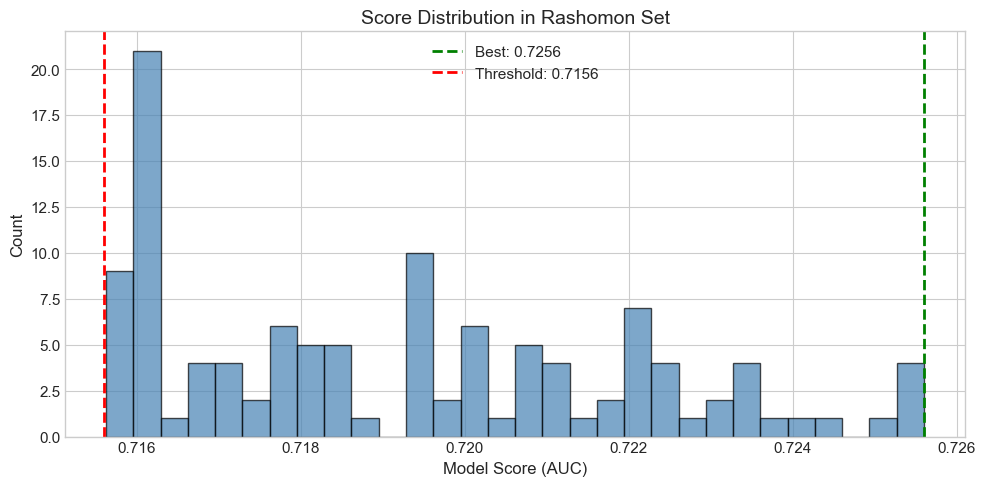

In [29]:
# Score distribution in Rashomon set
plot_score_distribution(rashomon)


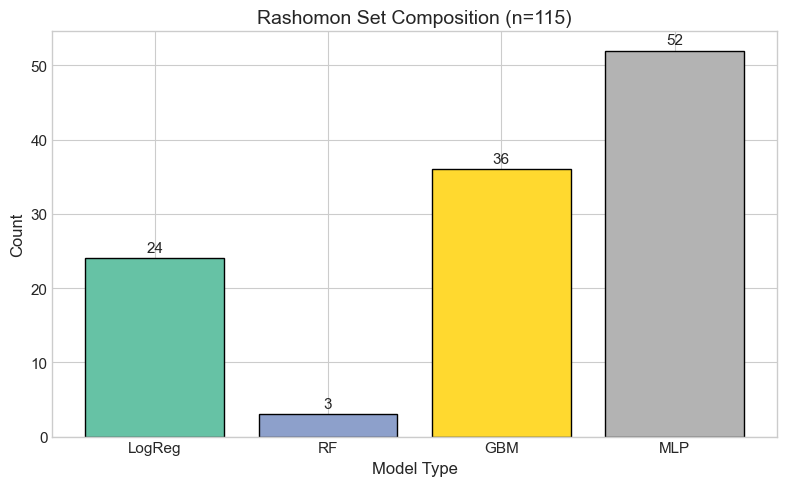

In [40]:
plot_rashomon_composition(rashomon)

## 3. Compute All Multiplicity Metrics

Run the full analysis pipeline: observation-wise variance, PDP variance, and FME variance.


In [30]:
# Run full multiplicity analysis
analysis = full_multiplicity_analysis(
    rashomon,
    X_test,
    y_test,
    feature_names,
    compute_pdp=True,
    compute_fme=True,
    verbose=True
)



📊 Running full multiplicity analysis...
   Computing observation-wise metrics...
   Computing PDP variance...


Computing PDP variance (numeric): 100%|██████████| 12/12 [00:54<00:00,  4.56s/it]


   Computing FME variance...


Computing FME variance: 100%|██████████| 5/5 [00:11<00:00,  2.23s/it]


           MULTIPLICITY METRICS SUMMARY

📊 Observation-wise Variance
   Mean variance:     0.002313
   Max variance:      0.041385
   High variance (>0.01): 55 samples (2.5%)

📊 Rashomon Prediction Intervals
   Mean 95% width:    0.1426
   Max 95% width:     0.6054
   Mean 50% width:    0.0689

📊 Classification Instability
   Controversial cases: 408 (18.8%)
   Mean flip prob:    0.0490
   Max flip prob:     0.4957

📊 Normalized Variance
   Mean (local):      0.0113
   Mean (global):     0.0093

📊 Top 5 Unstable Features (PDP):
   1. age: 0.005021
   2. priors_count: 0.002128
   3. c_charge_degree: 0.000573
   4. race: 0.000325
   5. sex: 0.000304

📊 Top 5 Unstable Features (FME):
   1. sex: 0.001224
   2. race: 0.000691
   3. age: 0.000386
   4. c_charge_degree: 0.000294
   5. priors_count: 0.000178


## 4. Visualizations

### 4.1 Observation-wise Variance

These plots analyze prediction instability at the individual sample level - identifying which observations have uncertain predictions across the Rashomon set.


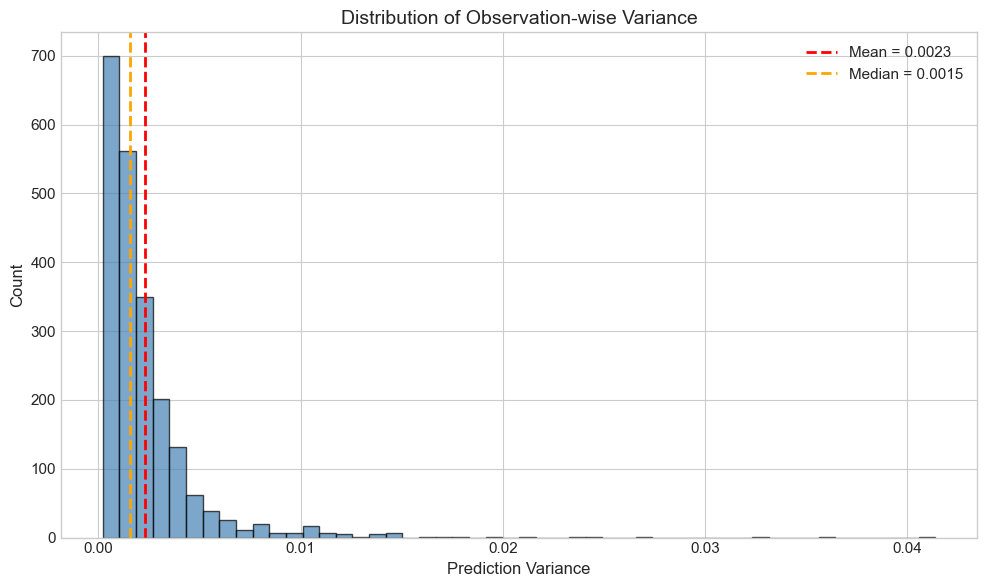

In [31]:
# Distribution of observation-wise variance
plot_variance_distribution(analysis['metrics'])


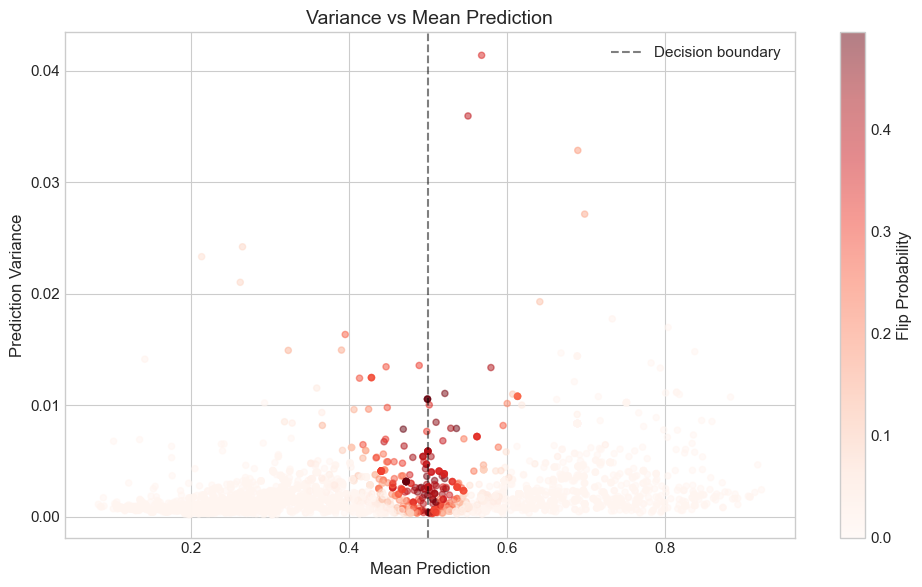

In [32]:
# Variance vs mean prediction
plot_variance_vs_prediction(analysis['metrics'])


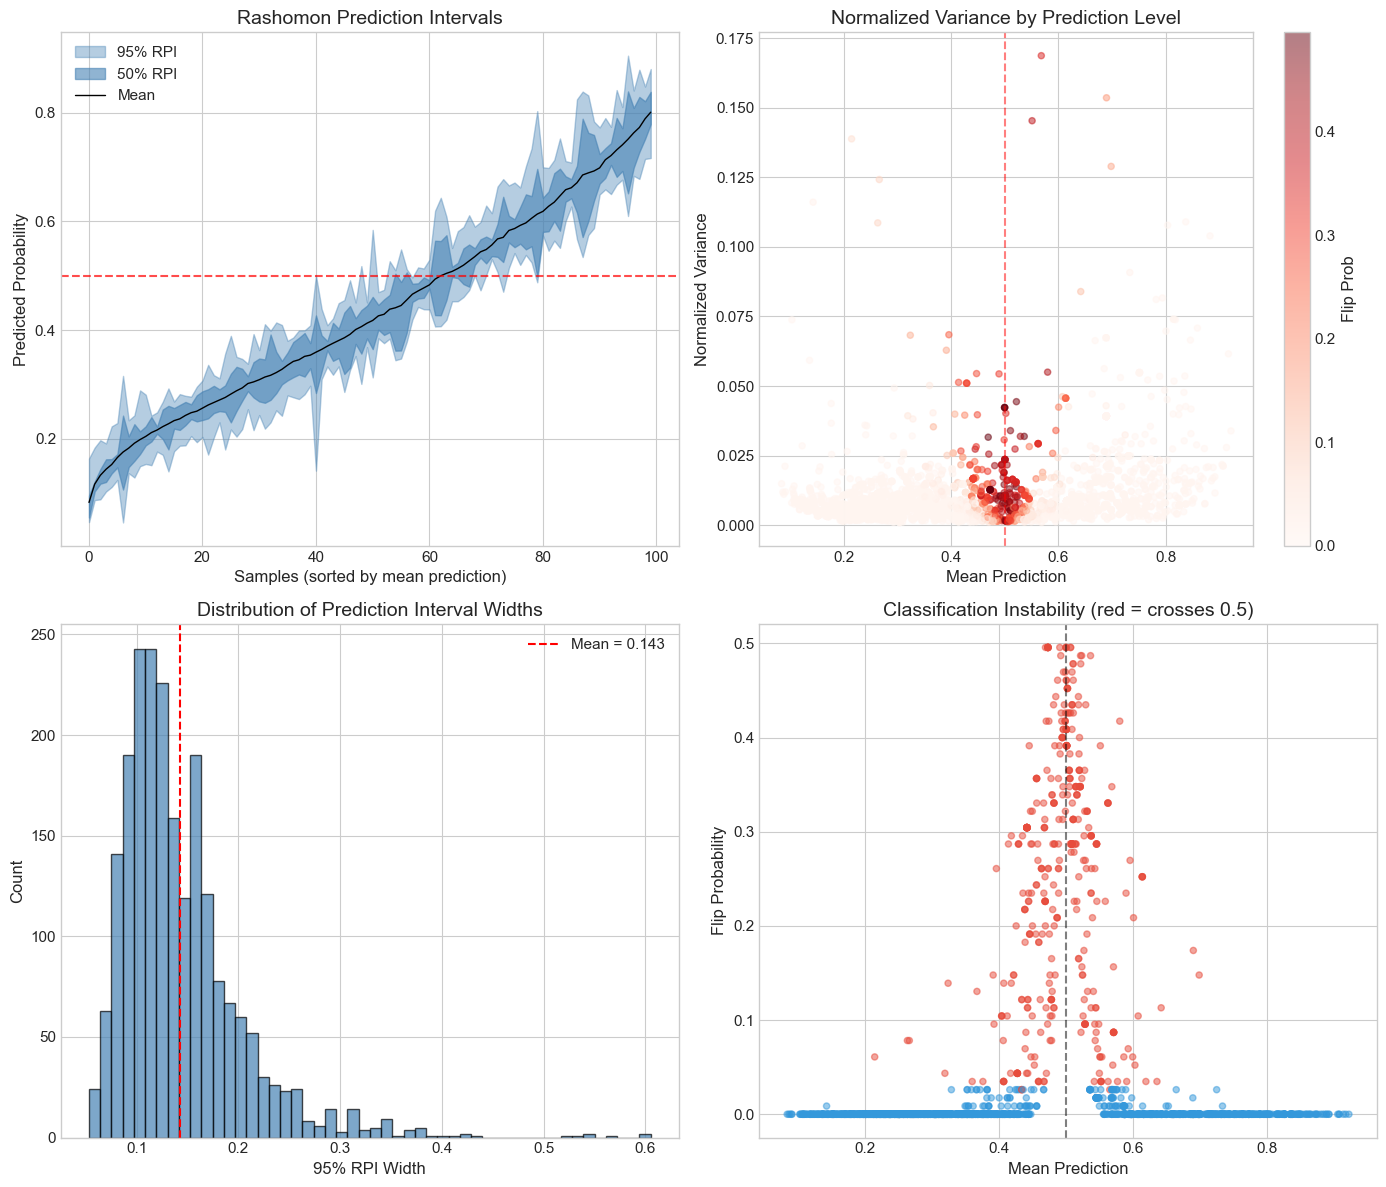

In [33]:
# Variance metrics: RPIs, normalized variance, flip probability
plot_variance_metrics(analysis['metrics'])


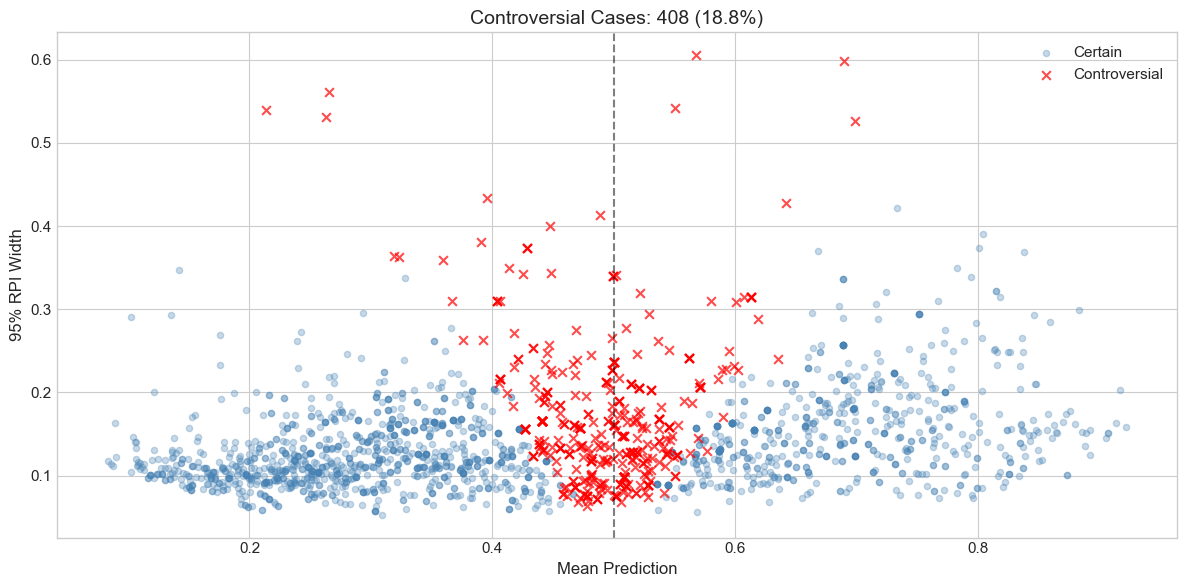

In [34]:
# Controversial cases visualization
plot_controversial_cases(analysis['metrics'], y_test=y_test)


### 4.2 PDP Instability (Global Feature Effects)

Partial Dependence Plot (PDP) variance measures how much the **global** feature effects vary across models. This answers: "Which features have unstable average effects?"


In [35]:
# Compute PDP variance if not already computed
if 'pdp_results' not in analysis:
    analysis['pdp_results'] = compute_pdp_variance(
        models=rashomon['models'],
        X=rashomon['X_test_scaled'],
        feature_names=feature_names,
        categorical_groups=categorical_groups,
        grid_size=50,
        verbose=True,
        scaler=rashomon.get('scaler'),
    )
    analysis['pdp_ranking'] = pdp_ranking(analysis['pdp_results'])


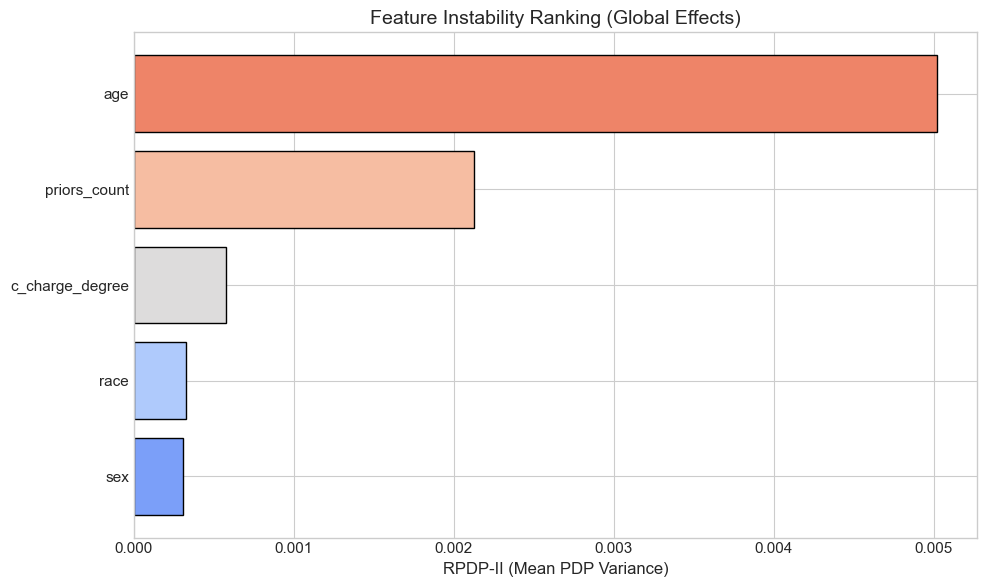

In [36]:
# PDP instability ranking
plot_pdp_ranking(analysis['pdp_ranking'])


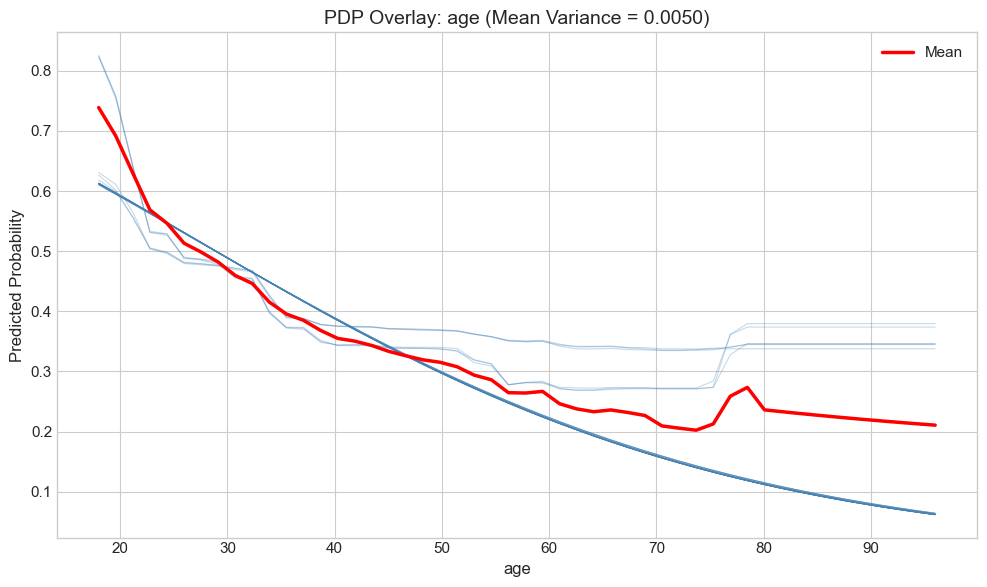

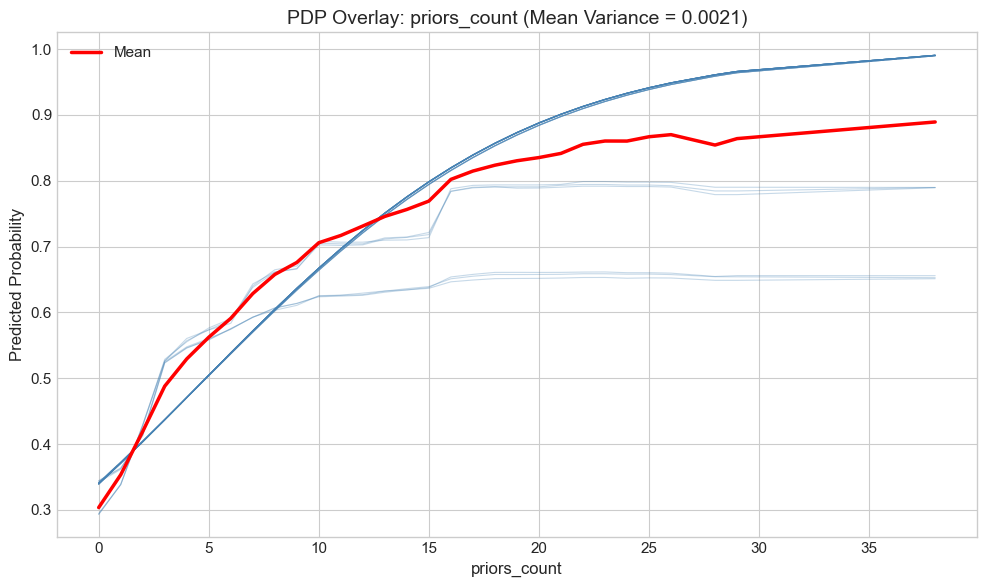

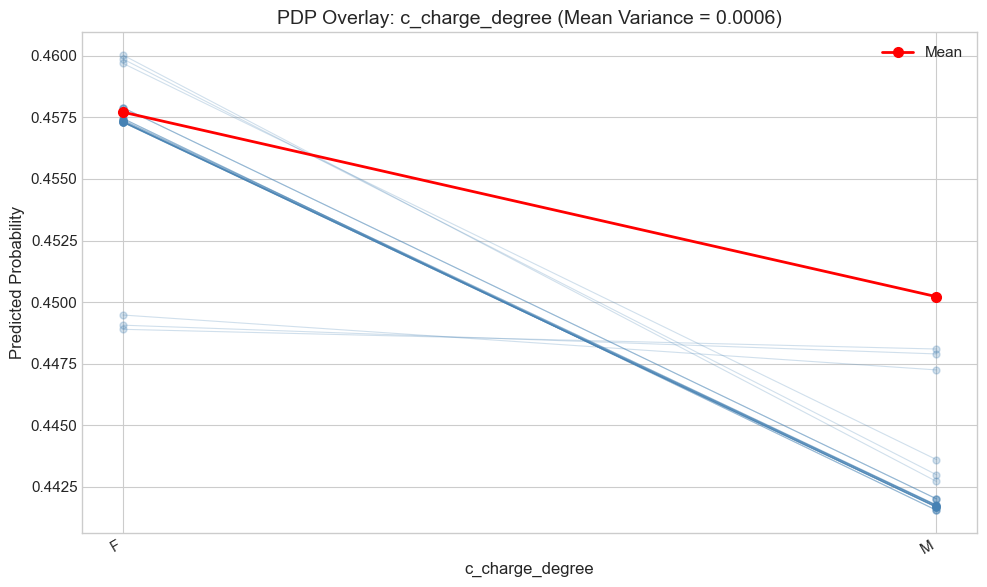

In [37]:
# PDP overlay for individual top features
top_pdp_features = analysis['pdp_ranking'].head(3).index
for fname in top_pdp_features:
    plot_pdp_overlay(analysis['pdp_results'][fname], fname, n_models=30)


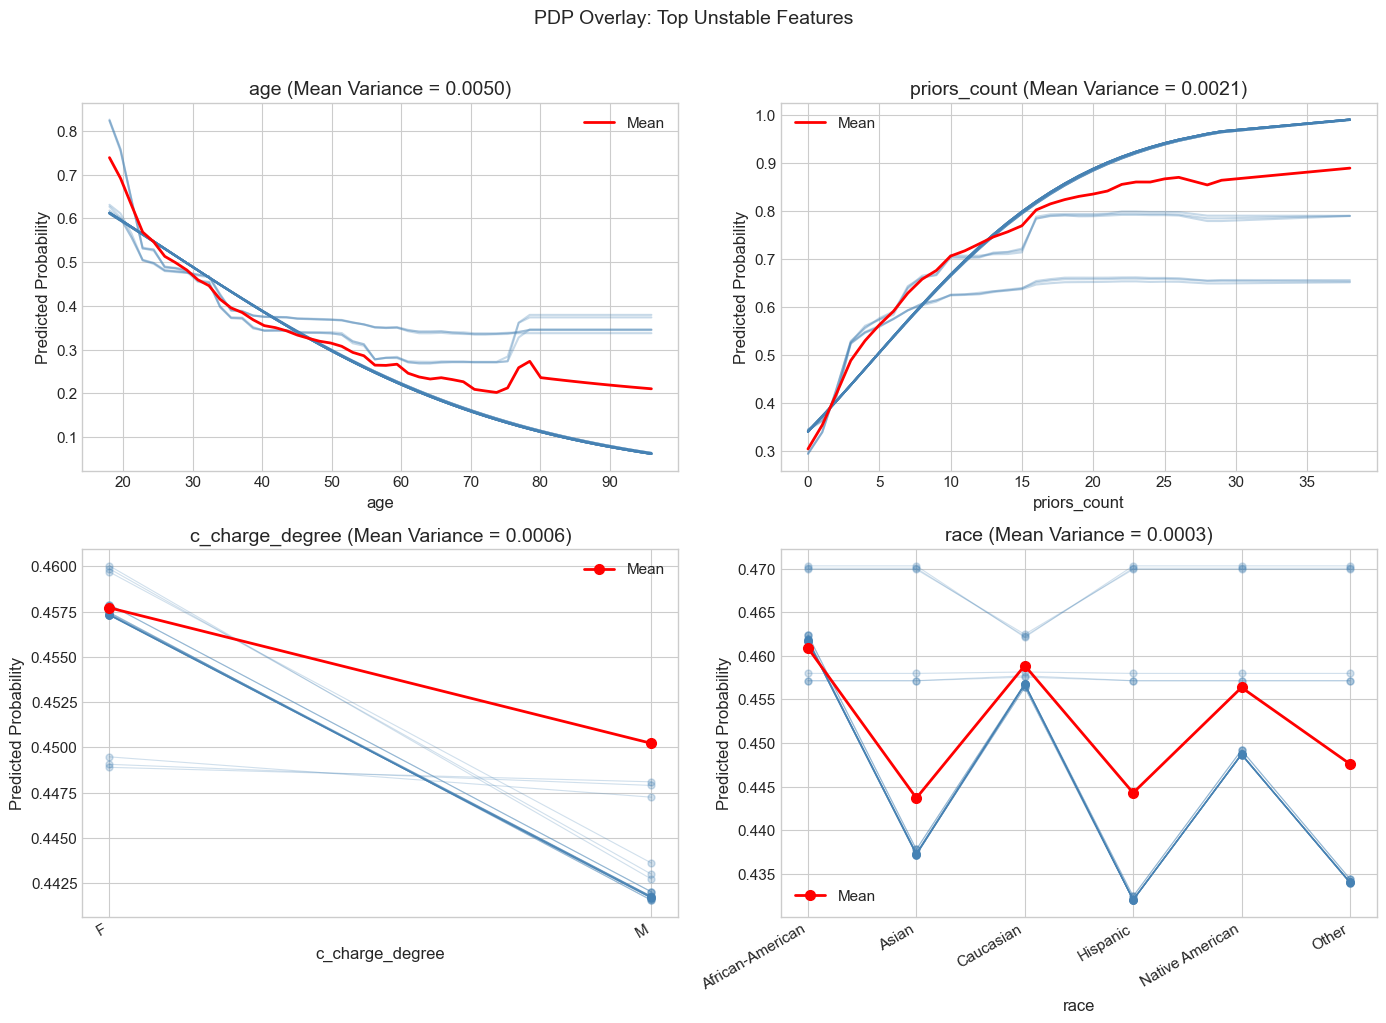

In [38]:
# PDP overlay for top 4 most unstable features
plot_pdp_top_features(analysis['pdp_results'], top_n=4)


### 4.3 FME Instability (Local Feature Effects)

Forward Marginal Effect (FME) variance measures how much the **local** feature effects vary across models for each individual sample. This answers: "Which features have unstable effects for specific observations?"


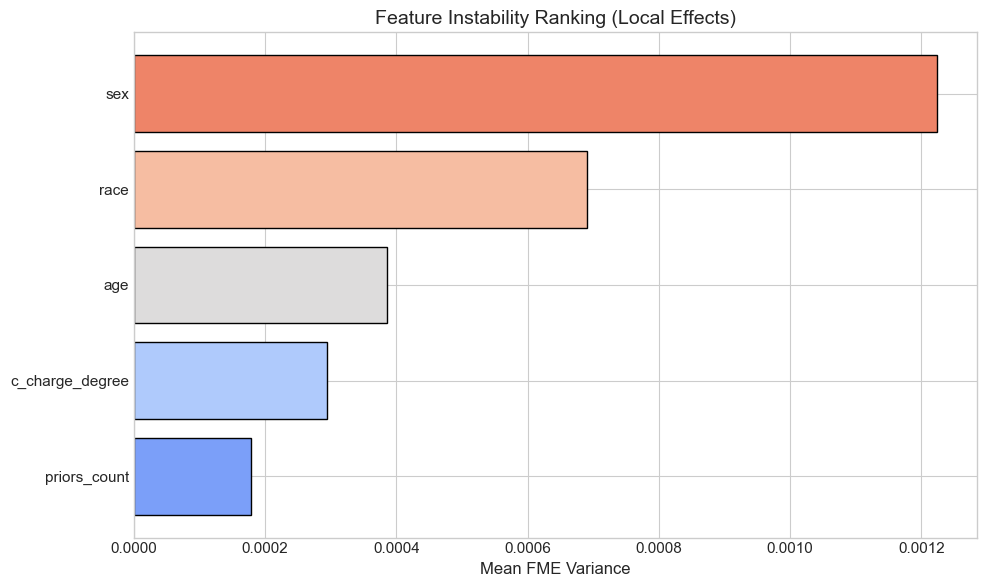

In [39]:
# Plot FME instability ranking
plot_fme_ranking(analysis['fme_ranking'])


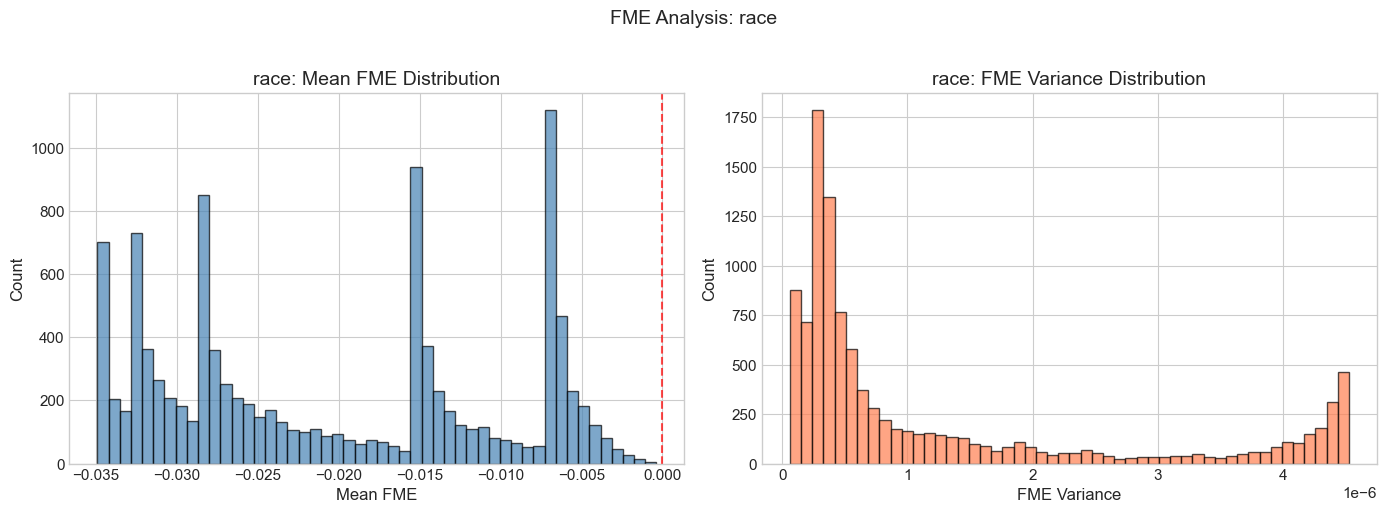

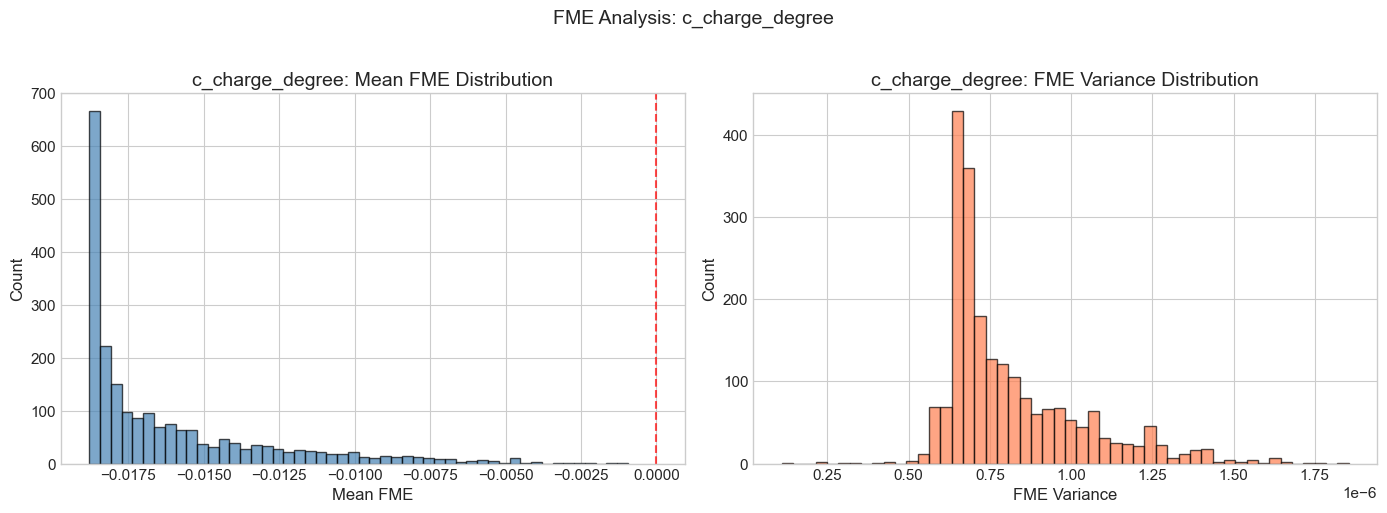

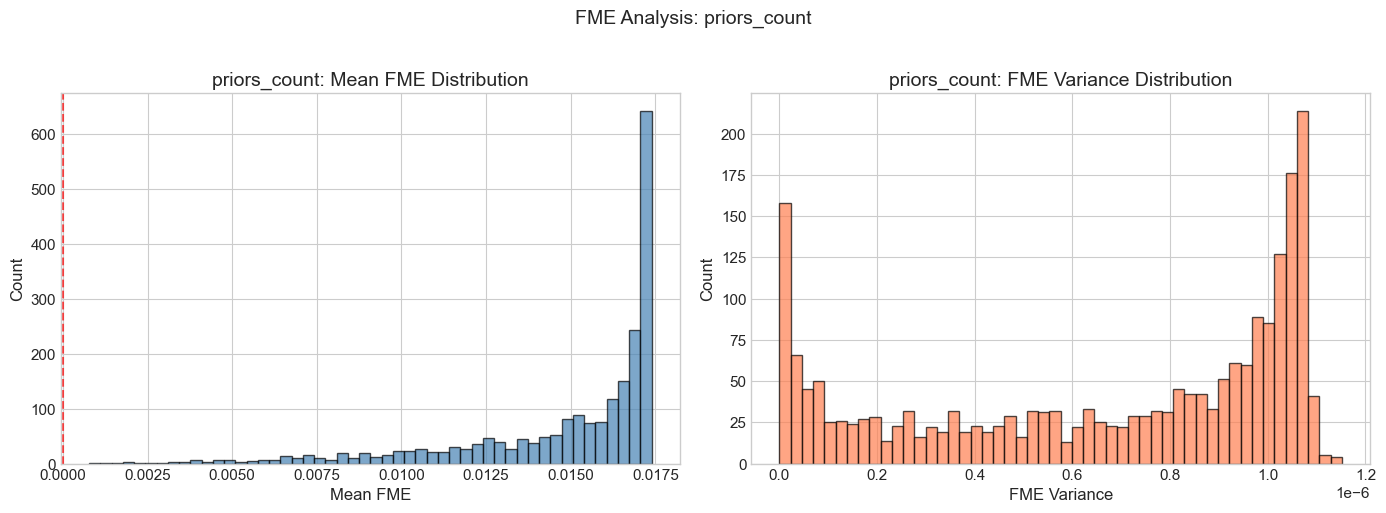

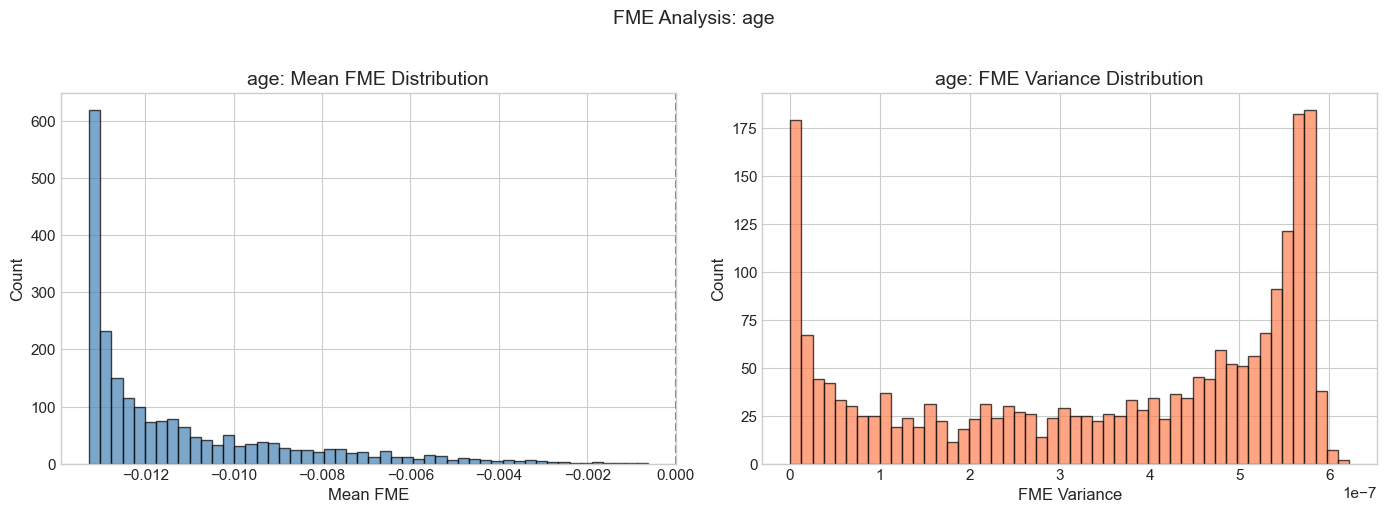

In [18]:
# FME distributions for the top 4 most unstable features
for fname in analysis['fme_ranking'].head(4).index:
    plot_fme_distribution(analysis['fme_results'][fname], fname)


## 5. Explore Results by Feature

These plots help identify patterns in variance across different feature values and combinations.


Results DataFrame shape: (2165, 26)


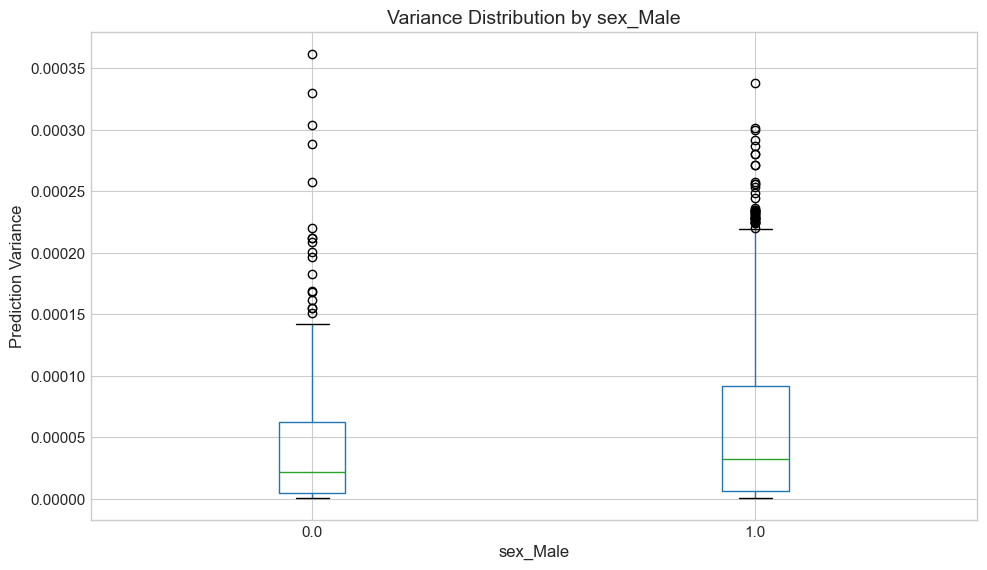

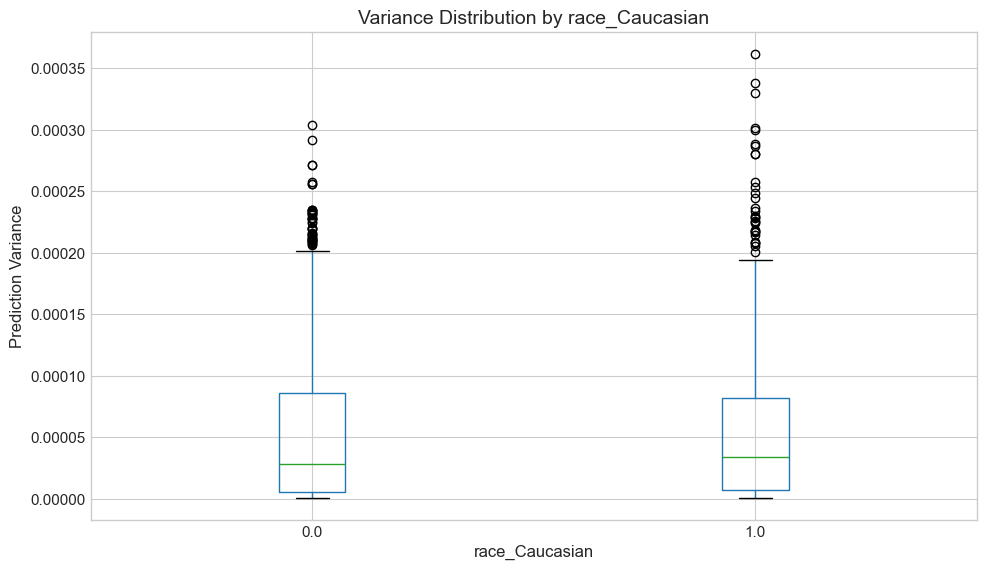

In [ ]:
# Get results DataFrame
df = analysis['metrics_df']
print(f"Results DataFrame shape: {df.shape}")

# Variance by feature
plot_variance_by_feature(df, 'sex_Male')
plot_variance_by_feature(df, 'race_Caucasian')


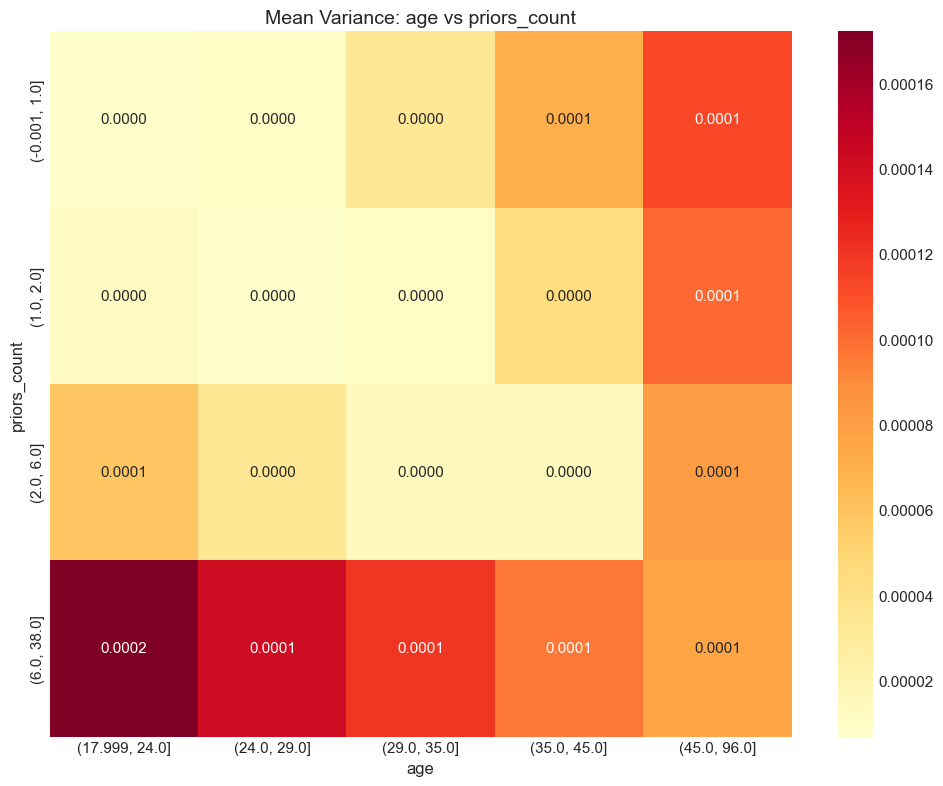

In [ ]:
# Heatmap of mean variance across two continuous features
plot_heatmap_variance_features(df, 'age', 'priors_count')


Controversial cases are samples where the 95% RPI crosses the 0.5 decision boundary - models disagree on classification.


In [22]:
# Controversial cases: where models disagree on classification
controversial = df[df['crosses_boundary']]
print(f"Controversial cases: {len(controversial)} ({100*len(controversial)/len(df):.1f}%)")
print(f"\nThese samples have 95% RPIs that cross the 0.5 decision boundary.")
controversial[['mean_pred', 'rpi_lower_95', 'rpi_upper_95', 'flip_probability', 'variance']].head(10)


Controversial cases: 54 (2.5%)

These samples have 95% RPIs that cross the 0.5 decision boundary.


,mean_pred,rpi_lower_95,rpi_upper_95,flip_probability,variance
5,0.496610,0.494692,0.505007,0.2,0.000011
69,0.504514,0.499496,0.505458,0.1,0.000003
86,0.499948,0.496491,0.500414,0.2,0.000001
109,0.499998,0.486128,0.503547,0.2,0.000037
123,0.502002,0.498071,0.502591,0.1,0.000002
187,0.503747,0.497589,0.505085,0.1,0.000005
225,0.494556,0.492509,0.503264,0.1,0.000013
236,0.498665,0.496863,0.506750,0.2,0.000010
289,0.503747,0.497589,0.505085,0.1,0.000005
330,0.500769,0.493962,0.502156,0.2,0.000006


In [23]:
# Controversial cases: where models disagree on classification
controversial = df[df['crosses_boundary']]
print(f"Controversial cases: {len(controversial)} ({100*len(controversial)/len(df):.1f}%)")
print(f"\nThese samples have 95% RPIs that cross the 0.5 decision boundary.")
controversial[['mean_pred', 'rpi_lower_95', 'rpi_upper_95', 'flip_probability', 'variance']].head(10)


Controversial cases: 54 (2.5%)

These samples have 95% RPIs that cross the 0.5 decision boundary.


,mean_pred,rpi_lower_95,rpi_upper_95,flip_probability,variance
5,0.496610,0.494692,0.505007,0.2,0.000011
69,0.504514,0.499496,0.505458,0.1,0.000003
86,0.499948,0.496491,0.500414,0.2,0.000001
109,0.499998,0.486128,0.503547,0.2,0.000037
123,0.502002,0.498071,0.502591,0.1,0.000002
187,0.503747,0.497589,0.505085,0.1,0.000005
225,0.494556,0.492509,0.503264,0.1,0.000013
236,0.498665,0.496863,0.506750,0.2,0.000010
289,0.503747,0.497589,0.505085,0.1,0.000005
330,0.500769,0.493962,0.502156,0.2,0.000006


## 6. Save All Figures

Generate and save all figures to a directory.


In [ ]:
# Uncomment to generate and save all figures
# plot_all(rashomon, analysis, save_dir='../figures')
